# OWM Configuration Experiments
**WorldView-3 | 31 development scenes | Pacific Northwest**

Systematic investigation to select the final OWM configuration used in owm_scenes_final.ipynb.
Four rounds run across 31 development scenes (not the 13 held-out test scenes).

**NOTE: Do not re-run — results saved to results/owm_experiments/**

- Cell 1: Setup
- Cell 2–5: Round 1 — Vector source comparison (OSM only, OSM+NHD, NHD only) → OSM+NHD selected
- Cell 6–11: Round 2 — Component analysis (no vector, manual NDWI, water vector only)
- Cell 12–15: Round 3 — U-Net model ablation (model+vector, model+vector+NDWI, model+NDWI only)
- Cell 16–20: Round 4 — Vector data quality assessment (OSM/NHD rasterised vs ground truth)

## Setup

In [1]:
# ── Setup ──
# Run this cell before any other cell in this notebook.import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import gc
import subprocess
import sys
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score

SCENE_DIR   = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/images/processed')
MASK_DIR    = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/images/masks')
NHD_GEOJSON = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/data/nhd/NHD_flowlines.geojson')
OUTPUT_DIR  = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/owm_experiments')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BAND_ORDER  = [1, 2, 3, 4]
NDWI_THRESH = 0.2
scene_files = sorted(SCENE_DIR.glob('*.tif'))

if not NHD_GEOJSON.exists():
    raise FileNotFoundError('NHD file not found. Run owm_nhd_supplementary.ipynb first.')

print(f'Scenes:   {len(scene_files)}')
print(f'NHD file: {NHD_GEOJSON.exists()}')
print(f'GPU:      {torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else "CPU only"}')

def load_mask(scene_name):
    p = MASK_DIR / f'{scene_name.replace("_rgbnir", "_watermask")}.tif'
    with rasterio.open(p) as src:
        return (src.read(1) > 0).astype(np.uint8)

def compute_metrics(pred, truth):
    p, t = pred.flatten(), truth.flatten()
    return {
        'f1':        round(f1_score(t, p, zero_division=0), 4),
        'iou':       round(jaccard_score(t, p, zero_division=0), 4),
        'precision': round(precision_score(t, p, zero_division=0), 4),
        'recall':    round(recall_score(t, p, zero_division=0), 4),
    }

def compute_ndwi_mask(scene_path, threshold=0.2):
    """Compute NDWI mask independently in Python at a given threshold."""
    with rasterio.open(scene_path) as src:
        green = src.read(2).astype(np.float32)
        nir   = src.read(4).astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)
    return (ndwi >= threshold).astype(np.uint8)

def run_owm_debug(scene_path, out_dir, **kwargs):
    """Run make_water_mask_debug in a subprocess so GPU memory is fully released."""
    out_dir.mkdir(parents=True, exist_ok=True)
    aux = kwargs.get('aux_vector_sources')
    aux_str = f"[Path(r'{aux[0]}')]" if aux else "None"

    script = f"""
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
from pathlib import Path
from omniwatermask import make_water_mask_debug
out_paths = make_water_mask_debug(
    scene_paths      = [Path(r'{scene_path}')],
    band_order       = [1, 2, 3, 4],
    output_dir       = Path(r'{out_dir}'),
    overwrite        = True,
    use_cache        = False,
    use_model        = {kwargs.get('use_model', True)},
    use_ndwi         = {kwargs.get('use_ndwi', False)},
    use_osm_water    = {kwargs.get('use_osm_water', False)},
    use_osm_building = {kwargs.get('use_osm_building', False)},
    use_osm_roads    = {kwargs.get('use_osm_roads', False)},
    aux_vector_sources = {aux_str},
)
print('OUTPUT_PATH:' + str(out_paths[0]))
"""
    result = subprocess.run(
        [sys.executable, '-c', script],
        capture_output=True, text=True, timeout=600
    )
    if result.returncode not in (0, -11):
        raise RuntimeError(result.stderr[-1000:])
    out_path = None
    for line in result.stdout.splitlines():
        if line.startswith('OUTPUT_PATH:'):
            out_path = Path(line.replace('OUTPUT_PATH:', '').strip())
            break
    if out_path is None or not out_path.exists():
        raise RuntimeError(f'Output file not found. stdout: {result.stdout[-500:]}')
    with rasterio.open(out_path) as src:
        return (src.read(1) > 0).astype(np.uint8)    

def run_owm(scene_path, out_dir, **kwargs):
    """Run OWM in a subprocess so GPU memory is fully released after each scene."""
    out_dir.mkdir(parents=True, exist_ok=True)

    aux = kwargs.get('aux_vector_sources')
    aux_str = f"[Path(r'{aux[0]}')]" if aux else "None"

    script = f"""
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
from pathlib import Path
from omniwatermask import make_water_mask
out_paths = make_water_mask(
    scene_paths        = [Path(r'{scene_path}')],
    band_order         = [1, 2, 3, 4],
    output_dir         = Path(r'{out_dir}'),
    overwrite          = True,
    use_cache          = False,
    use_osm_water      = {kwargs.get('use_osm_water', True)},
    use_osm_building   = {kwargs.get('use_osm_building', True)},
    use_osm_roads      = {kwargs.get('use_osm_roads', True)},
    aux_vector_sources = {aux_str},
)
print('OUTPUT_PATH:' + str(out_paths[0]))
"""
    result = subprocess.run(
        [sys.executable, '-c', script],
        capture_output=True, text=True, timeout=600
    )

    # -11 = SIGSEGV during cleanup after successful write — treat as success
    # Only raise on other non-zero codes
    if result.returncode not in (0, -11):
        raise RuntimeError(result.stderr[-1000:])

    # Parse output path
    out_path = None
    for line in result.stdout.splitlines():
        if line.startswith('OUTPUT_PATH:'):
            out_path = Path(line.replace('OUTPUT_PATH:', '').strip())
            break

    if out_path is None or not out_path.exists():
        raise RuntimeError(f'Output file not found. stdout: {result.stdout[-500:]}')

    with rasterio.open(out_path) as src:
        return (src.read(1) > 0).astype(np.uint8)

def run_all_scenes(label, out_subdir, get_pred_fn):
    """Run get_pred_fn across all scenes, compute metrics, return DataFrame."""
    results = []
    out_dir = OUTPUT_DIR / out_subdir
    print(f'\n── {label} ──')
    for scene_path in scene_files:
        scene_name = scene_path.stem
        mask_path  = MASK_DIR / f'{scene_name.replace("_rgbnir", "_watermask")}.tif'
        if not mask_path.exists():
            print(f'  {scene_name[-30:]}: no mask, skipping')
            continue
        try:
            pred    = get_pred_fn(scene_path, out_dir)
            truth   = load_mask(scene_name)
            metrics = compute_metrics(pred, truth)
            metrics.update({'scene': scene_name, 'method': label})
            results.append(metrics)
            print(f'  {scene_name[-30:]}: F1={metrics["f1"]}  Prec={metrics["precision"]}  Rec={metrics["recall"]}')
        except Exception as e:
            print(f'  {scene_name[-30:]}: ERROR {e}')
            results.append({'scene': scene_name, 'method': label,
                            'f1': None, 'iou': None, 'precision': None, 'recall': None})
    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_DIR / f'{out_subdir}_results.csv', index=False)
    return df

def summarise(df):
    return df.dropna(subset=['f1'])[['f1','iou','precision','recall']].mean().round(4)

def plot_comparison(summary_df, title, filename):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    colors = ['#B4B2A9','#85B7EB','#5DCAA5','#378ADD','#1D9E75','#7F77DD','#D85A30']
    for ax, metric in zip(axes, ['f1','iou','precision','recall']):
        vals = summary_df[metric].fillna(0)
        bars = ax.bar(summary_df.index, vals, color=colors[:len(summary_df)], width=0.6)
        ax.set_title(metric.upper(), fontsize=12)
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=25)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.3f}', ha='center', fontsize=9)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

print('Setup complete.')

Scenes:   31
NHD file: True
GPU:      NVIDIA H100 NVL
Setup complete.


---
## Round 1 — Find best vector source
Tests three vector calibration configurations to find which best improves OWM performance.
All configurations run the full OWM pipeline (model + NDWI + vector).

- **OSM only** — default OWM behaviour
- **OSM + NHD** — adds US National Hydrography Dataset (294,148 flowlines) alongside OSM
- **NHD only** — disables OSM entirely, uses NHD as the sole vector source

**Winner: OSM + NHD (F1 0.329)** — used as the baseline OWM configuration in all subsequent rounds.

In [3]:
# Config A: OSM only (default OWM)
# NOTE: Do not re-run — results saved to results/owm_experiments/r1_*/

df_osm = run_all_scenes(
    label      = 'full_osm',
    out_subdir = 'r1_osm',
    get_pred_fn = lambda sp, od: run_owm(sp, od,
        use_osm_water=True, use_osm_building=True, use_osm_roads=True)
)


── full_osm ──
  0604_sub1.dat_881155641_rgbnir: F1=0.38  Prec=0.3129  Rec=0.4836
  2819_sub1.dat_303727505_rgbnir: F1=0.1699  Prec=0.3356  Rec=0.1138
  mfjd_sub.dat_1644634081_rgbnir: F1=0.3392  Prec=0.2328  Rec=0.6245
  18_sub_3.dat_1388741441_rgbnir: F1=0.2794  Prec=0.1628  Rec=0.9843
  18_sub_a.dat_1760163485_rgbnir: F1=0.2601  Prec=0.1499  Rec=0.9832
  433_sub1.dat_1742560552_rgbnir: F1=0.2347  Prec=0.1342  Rec=0.9337
  433_sub2.dat_1220613635_rgbnir: F1=0.0262  Prec=0.0133  Rec=0.9528
  3433_sub3.dat_882261914_rgbnir: F1=0.0808  Prec=0.0423  Rec=0.8872
  4194_sub1.dat_636854335_rgbnir: F1=0.0358  Prec=0.0183  Rec=0.8515
  711_mfjd.dat_1464274182_rgbnir: F1=0.6723  Prec=0.7109  Rec=0.6377
  1440_sub1.dat_537003824_rgbnir: F1=0.8032  Prec=0.7183  Rec=0.9109
  93_sub_1.dat_1195138591_rgbnir: F1=0.4783  Prec=0.3202  Rec=0.9443
  93_sub_2.dat_1744623452_rgbnir: F1=0.8404  Prec=0.8159  Rec=0.8664
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.6394
  93_sub_4.dat_13256

In [4]:
# Config B: OSM + NHD
# NOTE: Do not re-run — results saved to results/owm_experiments/r1_*/

df_osm_nhd = run_all_scenes(
    label      = 'osm_plus_nhd',
    out_subdir = 'r1_osm_nhd',
    get_pred_fn = lambda sp, od: run_owm(sp, od,
        use_osm_water=True, use_osm_building=True, use_osm_roads=True,
        aux_vector_sources=[NHD_GEOJSON])
)


── osm_plus_nhd ──
  0604_sub1.dat_881155641_rgbnir: F1=0.2949  Prec=0.1926  Rec=0.6294
  2819_sub1.dat_303727505_rgbnir: F1=0.6381  Prec=0.4858  Rec=0.9294
  mfjd_sub.dat_1644634081_rgbnir: F1=0.3741  Prec=0.2391  Rec=0.8595
  18_sub_3.dat_1388741441_rgbnir: F1=0.277  Prec=0.1612  Rec=0.9841
  18_sub_a.dat_1760163485_rgbnir: F1=0.2572  Prec=0.148  Rec=0.9834
  433_sub1.dat_1742560552_rgbnir: F1=0.2345  Prec=0.1341  Rec=0.9338
  433_sub2.dat_1220613635_rgbnir: F1=0.0238  Prec=0.012  Rec=0.9559
  3433_sub3.dat_882261914_rgbnir: F1=0.094  Prec=0.0495  Rec=0.9275
  4194_sub1.dat_636854335_rgbnir: F1=0.0356  Prec=0.0182  Rec=0.8561
  711_mfjd.dat_1464274182_rgbnir: F1=0.648  Prec=0.6101  Rec=0.6908
  1440_sub1.dat_537003824_rgbnir: F1=0.7956  Prec=0.7051  Rec=0.9128
  93_sub_1.dat_1195138591_rgbnir: F1=0.4802  Prec=0.3215  Rec=0.9483
  93_sub_2.dat_1744623452_rgbnir: F1=0.8326  Prec=0.783  Rec=0.8889
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.6444
  93_sub_4.dat_13256

In [5]:
# Config C: NHD only (OSM disabled)
# NOTE: Do not re-run — results saved to results/owm_experiments/r1_*/

df_nhd = run_all_scenes(
    label      = 'nhd_only',
    out_subdir = 'r1_nhd',
    get_pred_fn = lambda sp, od: run_owm(sp, od,
        use_osm_water=False, use_osm_building=False, use_osm_roads=False,
        aux_vector_sources=[NHD_GEOJSON])
)


── nhd_only ──
  0604_sub1.dat_881155641_rgbnir: F1=0.339  Prec=0.2436  Rec=0.5571
  2819_sub1.dat_303727505_rgbnir: F1=0.1646  Prec=0.296  Rec=0.114
  mfjd_sub.dat_1644634081_rgbnir: F1=0.3185  Prec=0.2152  Rec=0.6124
  18_sub_3.dat_1388741441_rgbnir: F1=0.2738  Prec=0.1597  Rec=0.9579
  18_sub_a.dat_1760163485_rgbnir: F1=0.2563  Prec=0.1474  Rec=0.9826
  433_sub1.dat_1742560552_rgbnir: F1=0.2166  Prec=0.1237  Rec=0.8714
  433_sub2.dat_1220613635_rgbnir: F1=0.0237  Prec=0.012  Rec=0.9534
  3433_sub3.dat_882261914_rgbnir: F1=0.0301  Prec=0.0158  Rec=0.3144
  4194_sub1.dat_636854335_rgbnir: F1=0.0309  Prec=0.0158  Rec=0.7428
  711_mfjd.dat_1464274182_rgbnir: F1=0.6218  Prec=0.5887  Rec=0.6588
  1440_sub1.dat_537003824_rgbnir: F1=0.771  Prec=0.6725  Rec=0.9032
  93_sub_1.dat_1195138591_rgbnir: F1=0.6211  Prec=0.4756  Rec=0.895
  93_sub_2.dat_1744623452_rgbnir: F1=0.7907  Prec=0.7194  Rec=0.8777
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.6511
  93_sub_4.dat_132563457

── Round 1 summary ──
                  f1     iou  precision  recall
full_osm      0.3183  0.2205     0.2512  0.8449
osm_plus_nhd  0.3285  0.2281     0.2441  0.8921
nhd_only      0.3054  0.2091     0.2330  0.8141


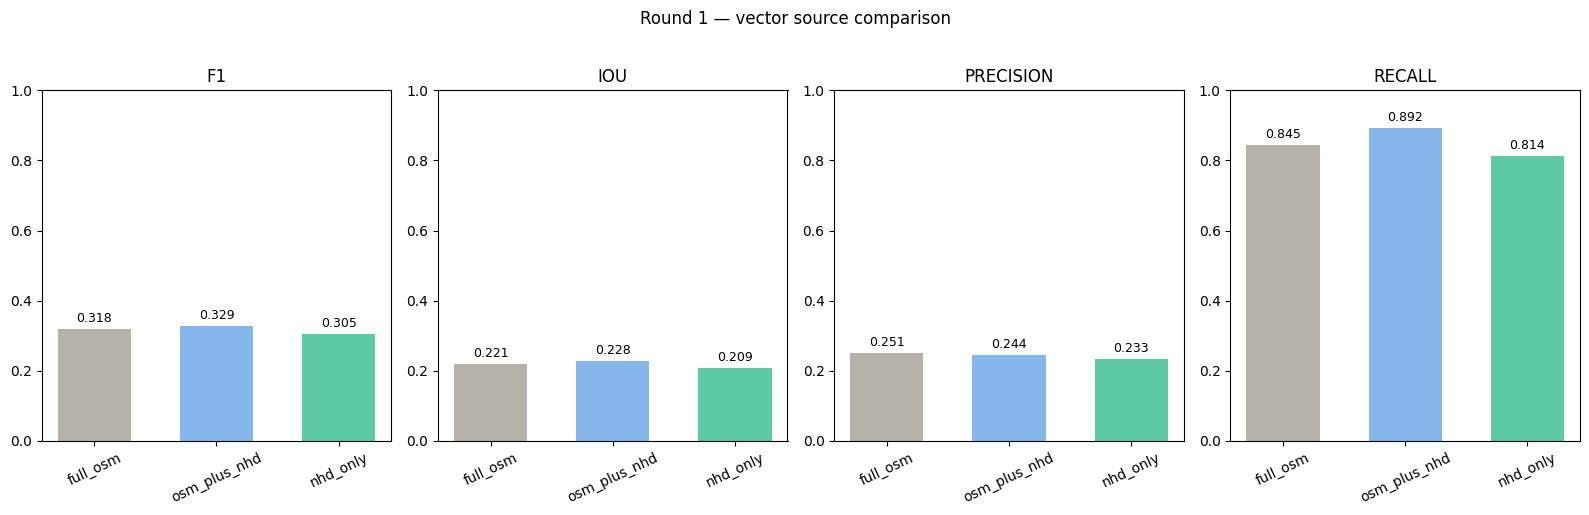


Best vector source: osm_plus_nhd


In [17]:
# Round 1 summary
# NOTE: Do not re-run — results saved to results/owm_experiments/r1_*/

r1_summary = pd.DataFrame({
    'full_osm':     summarise(df_osm),
    'osm_plus_nhd': summarise(df_osm_nhd),
    'nhd_only':     summarise(df_nhd),
}).T
r1_summary.to_csv(OUTPUT_DIR / 'round1_summary.csv')

print('── Round 1 summary ──')
print(r1_summary.to_string())
plot_comparison(r1_summary, 'Round 1 — vector source comparison', 'round1_comparison.png')

winner = r1_summary.loc[['full_osm','osm_plus_nhd','nhd_only'], 'f1'].idxmax()
print(f'\nBest vector source: {winner}')

---
## Round 2 — Component analysis
Using the best vector configuration from Round 1 (OSM + NHD), tests which components
of OWM are driving results by toggling them on and off.

- **osm_plus_nhd** — full OWM pipeline with OSM + NHD (Round 1 winner, reference point)
- **no_vector** — model + OWM-NDWI with no vector calibration at all
- **ndwi_manual_0.2** — manual NDWI at threshold 0.2, no OWM at all
- **water_vector_only** — OSM + NHD water layer only, building and road filters disabled

**Key comparisons:**
- osm_plus_nhd vs no_vector → is vector calibration helping?
- osm_plus_nhd vs ndwi_manual_0.2 → is OWM adding value over a simple spectral index?
- osm_plus_nhd vs water_vector_only → do building/road OSM filters contribute?

In [7]:
# Set winner from Round 1 — auto-set or override manually
# Options: 'full_osm' | 'osm_plus_nhd' | 'nhd_only'
# NOTE: Do not re-run — results saved to results/owm_experiments/r2_*/

ROUND2_VECTOR = winner  # change this if you want to override

vector_kwargs = {
    'full_osm':     dict(use_osm_water=True,  use_osm_building=True,  use_osm_roads=True,  aux_vector_sources=None),
    'osm_plus_nhd': dict(use_osm_water=True,  use_osm_building=True,  use_osm_roads=True,  aux_vector_sources=[NHD_GEOJSON]),
    'nhd_only':     dict(use_osm_water=False, use_osm_building=False, use_osm_roads=False, aux_vector_sources=[NHD_GEOJSON]),
}[ROUND2_VECTOR]

print(f'Round 2 using vector config: {ROUND2_VECTOR}')
print(f'Vector kwargs: {vector_kwargs}')

Round 2 using vector config: osm_plus_nhd
Vector kwargs: {'use_osm_water': True, 'use_osm_building': True, 'use_osm_roads': True, 'aux_vector_sources': [PosixPath('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/data/nhd/NHD_flowlines.geojson')]}


In [8]:
# Config 1: Full OWM with winning vector — reuse Round 1 results if available
# NOTE: Do not re-run — results saved to results/owm_experiments/r2_*/

r1_csv = OUTPUT_DIR / f'r1_{ROUND2_VECTOR.replace("osm_plus_nhd","osm_nhd").replace("full_osm","osm").replace("nhd_only","nhd")}_results.csv'
if r1_csv.exists():
    df_full = pd.read_csv(r1_csv)
    df_full['method'] = 'full_owm'
    print(f'Reusing Round 1 results from {r1_csv.name}')
else:
    df_full = run_all_scenes(
        label      = 'full_owm',
        out_subdir = 'r2_full_owm',
        get_pred_fn = lambda sp, od: run_owm(sp, od, **vector_kwargs)
    )

Reusing Round 1 results from r1_osm_nhd_results.csv


In [9]:
# Config 2: Model + OWM-NDWI, no vector calibration at all
# NOTE: Do not re-run — results saved to results/owm_experiments/r2_*/

df_no_vector = run_all_scenes(
    label      = 'no_vector',
    out_subdir = 'r2_no_vector',
    get_pred_fn = lambda sp, od: run_owm(sp, od,
        use_osm_water=False, use_osm_building=False, use_osm_roads=False,
        aux_vector_sources=None)
)


── no_vector ──
  0604_sub1.dat_881155641_rgbnir: F1=0.4138  Prec=0.4054  Rec=0.4225
  2819_sub1.dat_303727505_rgbnir: F1=0.0304  Prec=0.0975  Rec=0.018
  mfjd_sub.dat_1644634081_rgbnir: F1=0.2263  Prec=0.1607  Rec=0.3819
  18_sub_3.dat_1388741441_rgbnir: F1=0.279  Prec=0.1635  Rec=0.9502
  18_sub_a.dat_1760163485_rgbnir: F1=0.0922  Prec=0.0552  Rec=0.281
  433_sub1.dat_1742560552_rgbnir: F1=0.1687  Prec=0.0973  Rec=0.6306
  433_sub2.dat_1220613635_rgbnir: F1=0.0262  Prec=0.0133  Rec=0.9442
  3433_sub3.dat_882261914_rgbnir: F1=0.0091  Prec=0.0048  Rec=0.0919
  4194_sub1.dat_636854335_rgbnir: F1=0.0303  Prec=0.0155  Rec=0.7179
  711_mfjd.dat_1464274182_rgbnir: F1=0.4667  Prec=0.6804  Rec=0.3552
  1440_sub1.dat_537003824_rgbnir: F1=0.8049  Prec=0.7274  Rec=0.9009
  93_sub_1.dat_1195138591_rgbnir: F1=0.4645  Prec=0.3141  Rec=0.8918
  93_sub_2.dat_1744623452_rgbnir: F1=0.6446  Prec=0.7603  Rec=0.5595
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.6344
  93_sub_4.dat_13256

In [10]:
# Config 3: Your own NDWI at threshold 0.2 — no OWM at all
# This is a pure Python computation, no GPU needed
# NOTE: Do not re-run — results saved to results/owm_experiments/r2_*/

def ndwi_pred(scene_path, out_dir):
    return compute_ndwi_mask(scene_path, threshold=NDWI_THRESH)

df_ndwi = run_all_scenes(
    label      = 'ndwi_manual_0.2',
    out_subdir = 'r2_ndwi',
    get_pred_fn = ndwi_pred
)


── ndwi_manual_0.2 ──
  0604_sub1.dat_881155641_rgbnir: F1=0.1244  Prec=0.9941  Rec=0.0664
  2819_sub1.dat_303727505_rgbnir: F1=0.8033  Prec=0.8382  Rec=0.7711
  mfjd_sub.dat_1644634081_rgbnir: F1=0.661  Prec=0.6492  Rec=0.6733
  18_sub_3.dat_1388741441_rgbnir: F1=0.6113  Prec=0.448  Rec=0.9623
  18_sub_a.dat_1760163485_rgbnir: F1=0.7168  Prec=0.593  Rec=0.9062
  433_sub1.dat_1742560552_rgbnir: F1=0.6185  Prec=0.5564  Rec=0.6963
  433_sub2.dat_1220613635_rgbnir: F1=0.246  Prec=0.1522  Rec=0.6411
  3433_sub3.dat_882261914_rgbnir: F1=0.3306  Prec=0.2198  Rec=0.6666
  4194_sub1.dat_636854335_rgbnir: F1=0.3532  Prec=0.2237  Rec=0.8395
  711_mfjd.dat_1464274182_rgbnir: F1=0.2431  Prec=0.9607  Rec=0.1392
  1440_sub1.dat_537003824_rgbnir: F1=0.7913  Prec=0.9947  Rec=0.657
  93_sub_1.dat_1195138591_rgbnir: F1=0.8616  Prec=0.9804  Rec=0.7685
  93_sub_2.dat_1744623452_rgbnir: F1=0.8428  Prec=0.9954  Rec=0.7308
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.1636
  93_sub_4.dat_1

In [11]:
# Config 4: OWM with water vector only (no building/road filters)
# Tests whether building/road OSM layers are helping the filtering
# NOTE: Do not re-run — results saved to results/owm_experiments/r2_*/

water_only_kwargs = dict(vector_kwargs)
water_only_kwargs['use_osm_building'] = False
water_only_kwargs['use_osm_roads']    = False

df_water_only = run_all_scenes(
    label      = 'water_vector_only',
    out_subdir = 'r2_water_only',
    get_pred_fn = lambda sp, od: run_owm(sp, od, **water_only_kwargs)
)


── water_vector_only ──
  0604_sub1.dat_881155641_rgbnir: F1=0.2947  Prec=0.1924  Rec=0.6296
  2819_sub1.dat_303727505_rgbnir: F1=0.556  Prec=0.3926  Rec=0.9523
  mfjd_sub.dat_1644634081_rgbnir: F1=0.3501  Prec=0.2196  Rec=0.8626
  18_sub_3.dat_1388741441_rgbnir: F1=0.2678  Prec=0.155  Rec=0.9837
  18_sub_a.dat_1760163485_rgbnir: F1=0.2546  Prec=0.1462  Rec=0.9834
  433_sub1.dat_1742560552_rgbnir: F1=0.2332  Prec=0.1332  Rec=0.9353
  433_sub2.dat_1220613635_rgbnir: F1=0.0237  Prec=0.012  Rec=0.9563
  3433_sub3.dat_882261914_rgbnir: F1=0.0938  Prec=0.0494  Rec=0.9283
  4194_sub1.dat_636854335_rgbnir: F1=0.0346  Prec=0.0177  Rec=0.8591
  711_mfjd.dat_1464274182_rgbnir: F1=0.6423  Prec=0.5932  Rec=0.7003
  1440_sub1.dat_537003824_rgbnir: F1=0.7276  Prec=0.6056  Rec=0.9112
  93_sub_1.dat_1195138591_rgbnir: F1=0.4778  Prec=0.3192  Rec=0.95
  93_sub_2.dat_1744623452_rgbnir: F1=0.7906  Prec=0.7089  Rec=0.8936
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.6561
  93_sub_4.dat

── Round 2 summary ──
                       f1     iou  precision  recall
osm_plus_nhd       0.3285  0.2281     0.2441  0.8921
no_vector          0.2622  0.1762     0.2181  0.6906
ndwi_manual_0.2    0.4843  0.3745     0.5417  0.6667
water_vector_only  0.3142  0.2143     0.2271  0.8945


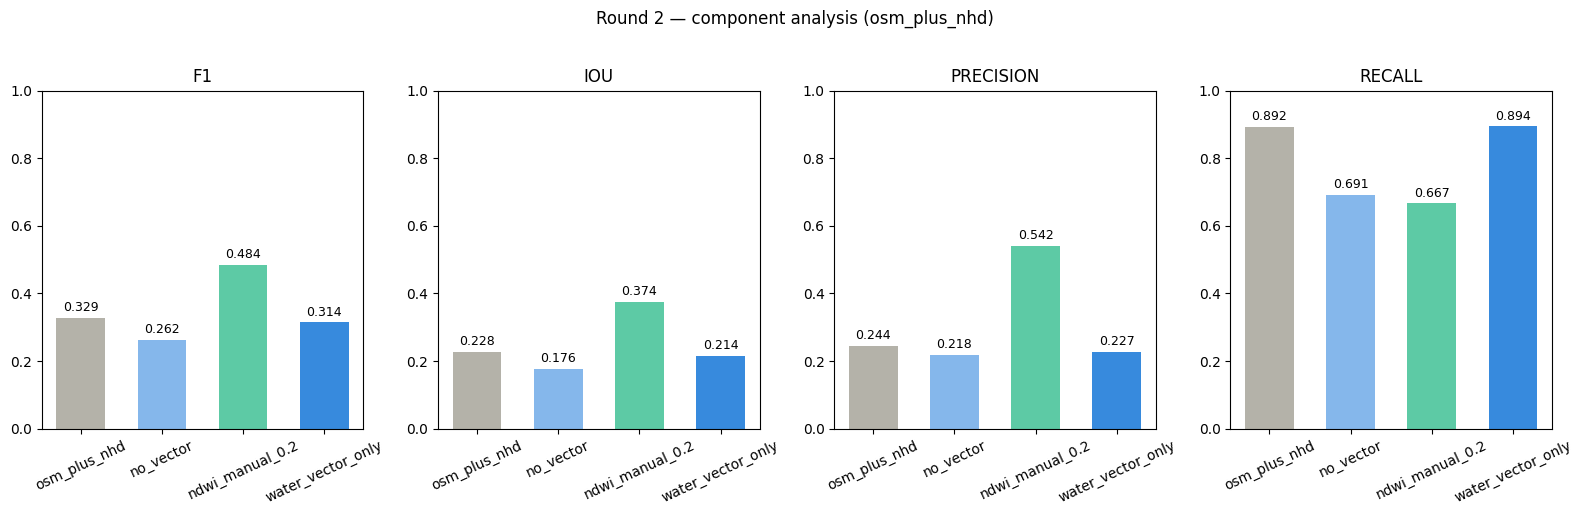

In [25]:
# Round 2 summary
# NOTE: Do not re-run — results saved to results/owm_experiments/r2_*/

r2_summary = pd.DataFrame({
    'osm_plus_nhd':          summarise(df_osm_nhd),
    'no_vector':         summarise(df_no_vector),
    'ndwi_manual_0.2':   summarise(df_ndwi),
    'water_vector_only': summarise(df_water_only),
}).T
r2_summary.to_csv(OUTPUT_DIR / 'round2_summary.csv')

print('── Round 2 summary ──')
print(r2_summary.to_string())
plot_comparison(r2_summary, f'Round 2 — component analysis ({ROUND2_VECTOR})', 'round2_comparison.png')

---
## Round 3 — U-Net model component analysis
Tests the OWM U-Net model in three configurations, compared against
the best results from previous rounds as reference points.

OWM requires either NDWI or vector to be enabled alongside the model.
Manual NDWI at threshold 0.2 is computed independently in Python and
unioned with the model output where applicable.

**Three new experiments:**
- **unet + vector** — U-Net with OSM+NHD calibration, internal NDWI disabled
- **unet + vector + manual NDWI 0.2** — U-Net with OSM+NHD, unioned with manual NDWI at 0.2
- **unet + no vector + manual NDWI 0.2** — U-Net with no vector calibration, unioned with manual NDWI at 0.2

**Reference points from previous rounds:**
- **ndwi_manual_0.2** — manual NDWI at threshold 0.2 only (Round 2 best result)
- **osm_plus_nhd** — full OWM with OSM+NHD (Round 1 best OWM configuration)

**Key comparisons:**
- unet+vector vs osm_plus_nhd → does disabling OWM's internal NDWI help or hurt?
- unet+vector+manual vs unet+vector → does adding manual NDWI 0.2 improve results?
- unet+no_vector+manual vs ndwi_manual_0.2 → does the U-Net add value over NDWI alone?

In [33]:
# NOTE: Do not re-run — results saved to results/owm_experiments/r3_*/

df_unet_vector = run_all_scenes(
    label      = 'unet+vector',
    out_subdir = 'r3_unet_vector',
    get_pred_fn = lambda sp, od: run_owm_debug(sp, od,
        use_model=True, use_ndwi=False,
        use_osm_water=True, use_osm_building=True, use_osm_roads=True,
        aux_vector_sources=[NHD_GEOJSON])
)


── unet+vector ──
  0604_sub1.dat_881155641_rgbnir: F1=0.0517  Prec=0.1714  Rec=0.0304
  2819_sub1.dat_303727505_rgbnir: F1=0.1408  Prec=0.3547  Rec=0.0878
  mfjd_sub.dat_1644634081_rgbnir: F1=0.1928  Prec=0.5847  Rec=0.1154
  18_sub_3.dat_1388741441_rgbnir: F1=0.5834  Prec=0.7237  Rec=0.4887
  18_sub_a.dat_1760163485_rgbnir: F1=0.0906  Prec=0.6522  Rec=0.0487
  433_sub1.dat_1742560552_rgbnir: F1=0.0072  Prec=0.0847  Rec=0.0038
  433_sub2.dat_1220613635_rgbnir: F1=0.2895  Prec=0.4159  Rec=0.222
  3433_sub3.dat_882261914_rgbnir: F1=0.1267  Prec=0.4446  Rec=0.0739
  4194_sub1.dat_636854335_rgbnir: F1=0.4641  Prec=0.6521  Rec=0.3602
  711_mfjd.dat_1464274182_rgbnir: F1=0.297  Prec=0.4325  Rec=0.2261
  1440_sub1.dat_537003824_rgbnir: F1=0.1874  Prec=0.6504  Rec=0.1095
  93_sub_1.dat_1195138591_rgbnir: F1=0.4907  Prec=0.577  Rec=0.4269
  93_sub_2.dat_1744623452_rgbnir: F1=0.4017  Prec=0.8464  Rec=0.2633
  93_sub_3.dat_1905672838_rgbnir: F1=0.0001  Prec=0.0  Rec=0.0067
  93_sub_4.dat_132563

In [34]:
# NOTE: Do not re-run — results saved to results/owm_experiments/r3_*/

def unet_vector_plus_ndwi(scene_path, out_dir):
    model_pred = run_owm_debug(scene_path, out_dir,
        use_model=True, use_ndwi=False,
        use_osm_water=True, use_osm_building=True, use_osm_roads=True,
        aux_vector_sources=[NHD_GEOJSON])
    ndwi_pred  = compute_ndwi_mask(scene_path, threshold=NDWI_THRESH)
    return np.maximum(model_pred, ndwi_pred)

df_unet_vector_ndwi = run_all_scenes(
    label      = 'unet+vector+manual_ndwi',
    out_subdir = 'r3_unet_vector_ndwi',
    get_pred_fn = unet_vector_plus_ndwi
)


── unet+vector+manual_ndwi ──
  0604_sub1.dat_881155641_rgbnir: F1=0.1553  Prec=0.3958  Rec=0.0966
  2819_sub1.dat_303727505_rgbnir: F1=0.7593  Prec=0.732  Rec=0.7887
  mfjd_sub.dat_1644634081_rgbnir: F1=0.6534  Prec=0.612  Rec=0.7007
  18_sub_3.dat_1388741441_rgbnir: F1=0.5886  Prec=0.4222  Rec=0.9718
  18_sub_a.dat_1760163485_rgbnir: F1=0.7133  Prec=0.5864  Rec=0.9103
  433_sub1.dat_1742560552_rgbnir: F1=0.6084  Prec=0.5395  Rec=0.6976
  433_sub2.dat_1220613635_rgbnir: F1=0.2626  Prec=0.1599  Rec=0.7339
  3433_sub3.dat_882261914_rgbnir: F1=0.3298  Prec=0.2175  Rec=0.6826
  4194_sub1.dat_636854335_rgbnir: F1=0.3513  Prec=0.2201  Rec=0.8691
  711_mfjd.dat_1464274182_rgbnir: F1=0.3954  Prec=0.5149  Rec=0.321
  1440_sub1.dat_537003824_rgbnir: F1=0.787  Prec=0.9175  Rec=0.6889
  93_sub_1.dat_1195138591_rgbnir: F1=0.7442  Prec=0.706  Rec=0.7866
  93_sub_2.dat_1744623452_rgbnir: F1=0.8456  Prec=0.9377  Rec=0.7699
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.1703
  93_sub

In [3]:
# NOTE: Do not re-run — results saved to results/owm_experiments/r3_*/

def unet_no_vector_plus_ndwi(scene_path, out_dir):
    model_pred = run_owm_debug(scene_path, out_dir,
        use_model=True, use_ndwi=True,
        use_osm_water=False, use_osm_building=False, use_osm_roads=False)
    ndwi_pred  = compute_ndwi_mask(scene_path, threshold=NDWI_THRESH)
    return np.maximum(model_pred, ndwi_pred)

df_unet_no_vector_ndwi = run_all_scenes(
    label      = 'unet+no_vector+manual_ndwi',
    out_subdir = 'r3_unet_no_vector_ndwi',
    get_pred_fn = unet_no_vector_plus_ndwi
)


── unet+no_vector+manual_ndwi ──
  0604_sub1.dat_881155641_rgbnir: F1=0.4137  Prec=0.4053  Rec=0.4225
  2819_sub1.dat_303727505_rgbnir: F1=0.7503  Prec=0.7242  Rec=0.7782
  mfjd_sub.dat_1644634081_rgbnir: F1=0.3758  Prec=0.249  Rec=0.7654
  18_sub_3.dat_1388741441_rgbnir: F1=0.2731  Prec=0.1587  Rec=0.9772
  18_sub_a.dat_1760163485_rgbnir: F1=0.2663  Prec=0.1552  Rec=0.9366
  433_sub1.dat_1742560552_rgbnir: F1=0.2229  Prec=0.128  Rec=0.8613
  433_sub2.dat_1220613635_rgbnir: F1=0.0264  Prec=0.0134  Rec=0.9495
  3433_sub3.dat_882261914_rgbnir: F1=0.0676  Prec=0.0355  Rec=0.7059
  4194_sub1.dat_636854335_rgbnir: F1=0.0368  Prec=0.0188  Rec=0.8872
  711_mfjd.dat_1464274182_rgbnir: F1=0.5273  Prec=0.7131  Rec=0.4183
  1440_sub1.dat_537003824_rgbnir: F1=0.805  Prec=0.7274  Rec=0.9011
  93_sub_1.dat_1195138591_rgbnir: F1=0.4762  Prec=0.321  Rec=0.9218
  93_sub_2.dat_1744623452_rgbnir: F1=0.8169  Prec=0.8206  Rec=0.8133
  93_sub_3.dat_1905672838_rgbnir: F1=0.0002  Prec=0.0001  Rec=0.6444
  93

── Round 3 summary ──
                                f1     iou  precision  recall
unet+vector                 0.2065  0.1274     0.4955  0.1501
unet+vector+manual_ndwi     0.4903  0.3711     0.4818  0.6952
unet+no_vector+manual_ndwi  0.3182  0.2205     0.2560  0.8226
ndwi_manual_0.2             0.4843  0.3745     0.5417  0.6667
osm_plus_nhd                0.3285  0.2281     0.2441  0.8921


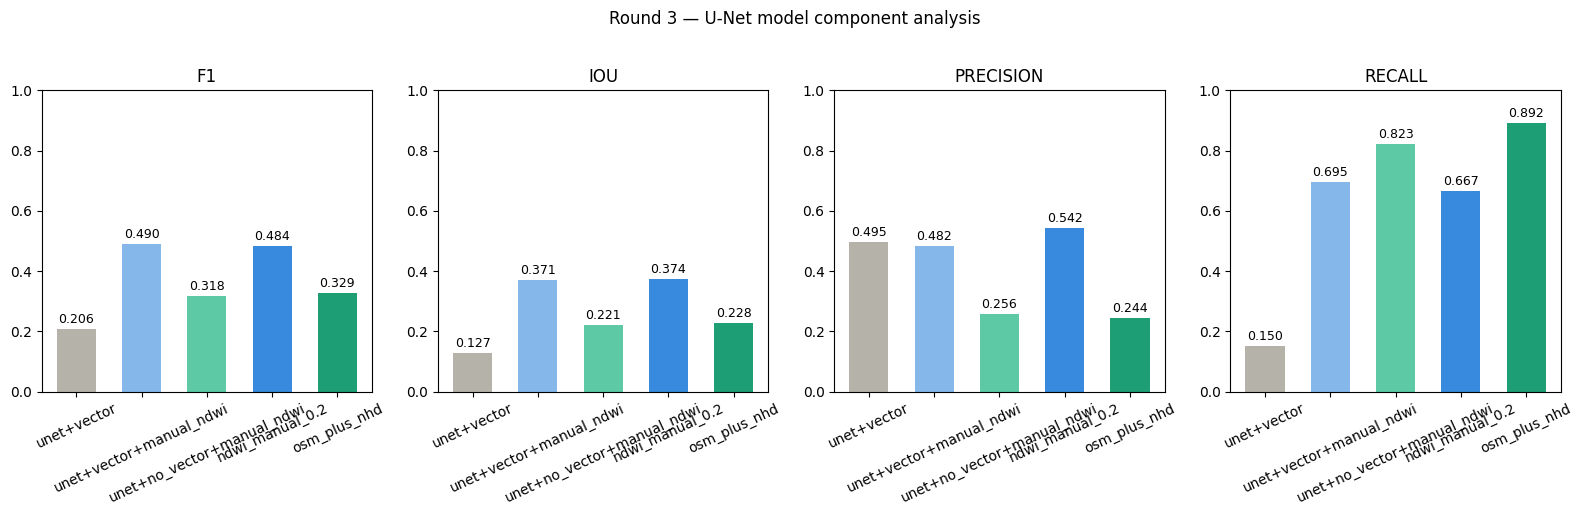


Key comparisons:
  unet+vector vs osm_plus_nhd          → does disabling NDWI help or hurt OWM?
  unet+vector+manual vs unet+vector    → does adding manual NDWI 0.2 improve results?
  unet+no_vector+manual vs ndwi_manual → does the U-Net add value over NDWI alone?


In [9]:
# NOTE: Do not re-run — results saved to results/owm_experiments/r3_*/

r3_summary = pd.DataFrame({
    'unet+vector':              summarise(df_unet_vector),
    'unet+vector+manual_ndwi':  summarise(df_unet_vector_ndwi),
    'unet+no_vector+manual_ndwi': summarise(df_unet_no_vector_ndwi),
    'ndwi_manual_0.2':          summarise(df_ndwi),
    'osm_plus_nhd':             summarise(df_osm_nhd),
}).T
r3_summary.to_csv(OUTPUT_DIR / 'round3_summary.csv')

print('── Round 3 summary ──')
print(r3_summary.to_string())
plot_comparison(r3_summary, 'Round 3 — U-Net model component analysis', 'round3_comparison.png')

print('\nKey comparisons:')
print('  unet+vector vs osm_plus_nhd          → does disabling NDWI help or hurt OWM?')
print('  unet+vector+manual vs unet+vector    → does adding manual NDWI 0.2 improve results?')
print('  unet+no_vector+manual vs ndwi_manual → does the U-Net add value over NDWI alone?')

---
## Round 4 — Vector Data Quality Assessment
Evaluates how well OSM and NHD represent the actual water extent in the study area,
using the manually annotated ground truth masks as reference.

**Motivation:** OWM uses OSM and NHD to calibrate its detection thresholds per scene.
If these vector sources incompletely represent water, the calibration is working with
incomplete reference data — which would directly explain OWM's low precision.
This round provides quantitative evidence for or against this hypothesis.

**Method:** OSM and NHD vector geometries are rasterised to match each scene's
resolution and extent, then evaluated against ground truth masks using the same
metrics as all previous rounds (F1, IoU, precision, recall).

**Important note on vector geometry type:** OSM and NHD store rivers as line
geometries (centrelines), not polygons. Ground truth masks cover the full water width.
Recall is therefore expected to be low due to this structural difference, not
necessarily because rivers are missing. A buffer analysis is included to separate
spatial accuracy from coverage completeness.

**Four configurations:**
- **OSM lines** — raw OSM water linestrings rasterised at scene resolution
- **OSM lines + buffer** — OSM lines expanded by 10m to approximate river width
- **NHD lines** — raw NHD flowlines rasterised at scene resolution
- **NHD lines + buffer** — NHD lines expanded by 10m to approximate river width

**Key questions:**
- OSM vs NHD → which vector source better represents water in this study area?
- raw vs buffer → are vectors spatially accurate but just narrow, or genuinely missing rivers?
- OSM/NHD recall vs OWM recall → does vector incompleteness explain OWM's calibration failures?

In [16]:
# NOTE: Do not re-run — results saved to results/owm_experiments/round4_vector_assessment/

import requests
import geopandas as gpd
from shapely.geometry import LineString, Polygon
from pathlib import Path

OSM_DIR = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/data/osm')
osm_path = OSM_DIR / 'osm_water.geojson'

query = f'[out:json][timeout:120];(way["waterway"]({south},{west},{north},{east});way["natural"="water"]({south},{west},{north},{east}););out geom;'

# Try different mirrors
mirrors = [
    'https://overpass.kumi.systems/api/interpreter',
    'https://overpass.openstreetmap.ru/api/interpreter',
    'https://maps.mail.ru/osm/tools/overpass/api/interpreter',
]

response = None
for mirror in mirrors:
    try:
        print(f'Trying {mirror}...')
        response = requests.get(mirror, params={'data': query}, timeout=120)
        print(f'  Status: {response.status_code}')
        if response.status_code == 200:
            print('  Success!')
            break
    except Exception as e:
        print(f'  Error: {e}')

if response and response.status_code == 200:
    data = response.json()
    print(f'Elements returned: {len(data["elements"])}')
else:
    print('All mirrors failed')

Trying https://overpass.kumi.systems/api/interpreter...
  Status: 200
  Success!
Elements returned: 32749


In [17]:
# NOTE: Do not re-run — results saved to results/owm_experiments/round4_vector_assessment/

features = []
for elem in data['elements']:
    if 'geometry' not in elem:
        continue
    coords = [(n['lon'], n['lat']) for n in elem['geometry']]
    if len(coords) < 2:
        continue
    try:
        tags = elem.get('tags', {})
        if tags.get('natural') == 'water' and coords[0] == coords[-1] and len(coords) >= 4:
            geom = Polygon(coords)
        else:
            geom = LineString(coords)
        features.append({
            'geometry': geom,
            'waterway': tags.get('waterway', ''),
            'natural':  tags.get('natural', ''),
            'name':     tags.get('name', ''),
        })
    except Exception:
        continue

osm = gpd.GeoDataFrame(features, crs='EPSG:4326')
osm = osm[osm.geometry.notna() & osm.geometry.is_valid]
osm.to_file(osm_path, driver='GeoJSON')

print(f'OSM saved: {len(osm)} features')
print(f'OSM geometry types: {osm.geometry.geom_type.value_counts().to_dict()}')
print(f'Waterway types: {osm["waterway"].value_counts().head(10).to_dict()}')

OSM saved: 32749 features
OSM geometry types: {'LineString': 27796, 'Polygon': 4953}
Waterway types: {'stream': 22812, '': 4953, 'canal': 1966, 'ditch': 1566, 'drain': 827, 'river': 379, 'dam': 145, 'weir': 32, 'link': 22, 'flowline': 16}


In [12]:
# NOTE: Do not re-run — results saved to results/owm_experiments/round4_vector_assessment/

NHD_GEOJSON = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/data/nhd/NHD_flowlines.geojson')
nhd = gpd.read_file(NHD_GEOJSON)
print(f'NHD loaded: {len(nhd)} features')
print(f'NHD geometry types: {nhd.geometry.geom_type.value_counts().to_dict()}')
print(f'NHD CRS: {nhd.crs}')

NHD loaded: 294148 features
NHD geometry types: {'LineString': 294148}
NHD CRS: EPSG:4326


In [19]:
# NOTE: Do not re-run — results saved to results/owm_experiments/round4_vector_assessment/

from rasterio.features import rasterize
from shapely.geometry import box

BUFFER_M  = 10
R4_OUTPUT = OUTPUT_DIR / 'round4_vector_assessment'
R4_OUTPUT.mkdir(exist_ok=True)

def rasterise_vectors(gdf, reference_raster_path, buffer_m=0):
    with rasterio.open(reference_raster_path) as src:
        transform    = src.transform
        shape        = (src.height, src.width)
        crs          = src.crs
        scene_bounds = src.bounds

    # Reproject to scene CRS first
    gdf_proj = gdf.to_crs(crs)

    if buffer_m > 0:
        # Buffer in metres requires a projected CRS
        # Use UTM zone appropriate for Pacific Northwest (EPSG:32610 = UTM Zone 10N)
        gdf_metric = gdf_proj.to_crs('EPSG:32610')
        gdf_metric = gdf_metric.copy()
        gdf_metric['geometry'] = gdf_metric.geometry.buffer(buffer_m)
        gdf_proj = gdf_metric.to_crs(crs)

    scene_box = box(*scene_bounds)
    gdf_proj  = gdf_proj[gdf_proj.geometry.intersects(scene_box)]

    if len(gdf_proj) == 0:
        return np.zeros(shape, dtype=np.uint8)

    burned = rasterize(
        [(geom, 1) for geom in gdf_proj.geometry if geom is not None and not geom.is_empty],
        out_shape   = shape,
        transform   = transform,
        fill        = 0,
        dtype       = np.uint8,
        all_touched = True
    )
    return burned

results = []

configs = [
    ('osm_raw',        osm, 0),
    ('osm_buffer_10m', osm, BUFFER_M),
    ('nhd_raw',        nhd, 0),
    ('nhd_buffer_10m', nhd, BUFFER_M),
]

for label, gdf, buf in configs:
    print(f'\n── {label} ──')
    for scene_path in scene_files:
        scene_name = scene_path.stem
        mask_path  = MASK_DIR / f'{scene_name.replace("_rgbnir", "_watermask")}.tif'
        if not mask_path.exists():
            continue
        try:
            pred  = rasterise_vectors(gdf, scene_path, buffer_m=buf)
            with rasterio.open(mask_path) as src:
                truth = (src.read(1) > 0).astype(np.uint8)
            metrics = compute_metrics(pred, truth)
            metrics.update({'scene': scene_name, 'method': label})
            results.append(metrics)
            print(f'  {scene_name[-30:]}: F1={metrics["f1"]}  Prec={metrics["precision"]}  Rec={metrics["recall"]}')
        except Exception as e:
            print(f'  {scene_name[-30:]}: ERROR {e}')
            results.append({'scene': scene_name, 'method': label,
                            'f1': None, 'iou': None, 'precision': None, 'recall': None})

df_r4 = pd.DataFrame(results)
df_r4.to_csv(R4_OUTPUT / 'round4_results.csv', index=False)
print('\nDone.')


── osm_raw ──
  0604_sub1.dat_881155641_rgbnir: F1=0.0314  Prec=0.0825  Rec=0.0194
  2819_sub1.dat_303727505_rgbnir: F1=0.066  Prec=0.6435  Rec=0.0348
  mfjd_sub.dat_1644634081_rgbnir: F1=0.0589  Prec=0.508  Rec=0.0313
  18_sub_3.dat_1388741441_rgbnir: F1=0.0624  Prec=0.2978  Rec=0.0349
  18_sub_a.dat_1760163485_rgbnir: F1=0.0566  Prec=0.4148  Rec=0.0304
  433_sub1.dat_1742560552_rgbnir: F1=0.3101  Prec=0.6057  Rec=0.2084
  433_sub2.dat_1220613635_rgbnir: F1=0.3319  Prec=0.463  Rec=0.2587
  3433_sub3.dat_882261914_rgbnir: F1=0.0646  Prec=0.1511  Rec=0.0411
  4194_sub1.dat_636854335_rgbnir: F1=0.082  Prec=0.2228  Rec=0.0503
  711_mfjd.dat_1464274182_rgbnir: F1=0.05  Prec=0.1956  Rec=0.0287
  1440_sub1.dat_537003824_rgbnir: F1=0.058  Prec=0.2734  Rec=0.0324
  93_sub_1.dat_1195138591_rgbnir: F1=0.0367  Prec=0.2006  Rec=0.0202
  93_sub_2.dat_1744623452_rgbnir: F1=0.3669  Prec=0.7624  Rec=0.2416
  93_sub_3.dat_1905672838_rgbnir: F1=0.0001  Prec=0.0001  Rec=0.0267
  93_sub_4.dat_1325634573_

── Round 4 summary ──
                        f1     iou  precision  recall
method                                               
nhd_buffer_10m      0.1618  0.0938     0.1168  0.4727
nhd_raw             0.0267  0.0136     0.1341  0.0171
osm_buffer_10m      0.3350  0.2158     0.2546  0.6565
osm_raw             0.0850  0.0470     0.3604  0.0541
osm_plus_nhd (OWM)  0.3290  0.2280     0.2440  0.8920
ndwi_manual_0.2     0.4840  0.3740     0.5420  0.6670


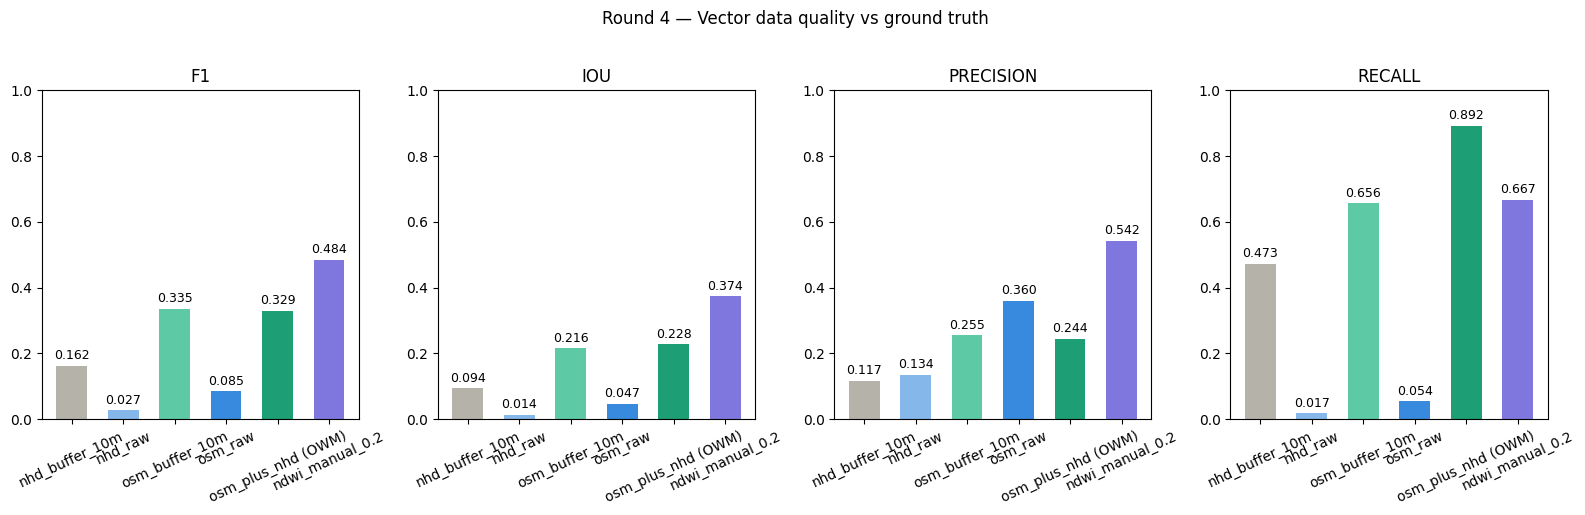


Key questions:
  osm_raw recall    → what % of actual water does OSM map?
  nhd_raw recall    → what % of actual water does NHD map?
  buffer improvement → are vectors accurate but just narrow?
  vs OWM recall     → does vector incompleteness explain OWM calibration failures?


In [20]:
# NOTE: Do not re-run — results saved to results/owm_experiments/round4_vector_assessment/

df_valid  = df_r4.dropna(subset=['f1'])
r4_summary = df_valid.groupby('method')[['f1','iou','precision','recall']].mean().round(4)

ref = pd.DataFrame([
    {'method': 'osm_plus_nhd (OWM)', 'f1': 0.329, 'iou': 0.228, 'precision': 0.244, 'recall': 0.892},
    {'method': 'ndwi_manual_0.2',    'f1': 0.484, 'iou': 0.374, 'precision': 0.542, 'recall': 0.667},
]).set_index('method')

r4_summary = pd.concat([r4_summary, ref])
r4_summary.to_csv(R4_OUTPUT / 'round4_summary.csv')

print('── Round 4 summary ──')
print(r4_summary.to_string())
plot_comparison(r4_summary, 'Round 4 — Vector data quality vs ground truth', 'round4_comparison.png')

print('\nKey questions:')
print('  osm_raw recall    → what % of actual water does OSM map?')
print('  nhd_raw recall    → what % of actual water does NHD map?')
print('  buffer improvement → are vectors accurate but just narrow?')
print('  vs OWM recall     → does vector incompleteness explain OWM calibration failures?')